In [432]:
### Libraries
using LinearAlgebra
using DelimitedFiles
using DifferentialEquations
using Tullio
⊗(A,B) = kron(A,B) ;

### Initial parameters

In [456]:
### Constants
MBOHR = 0.1#5.788381e-5         ### Bohrs magneton
KB = 8.6173324e-5           ### Bolzmann factor
GAMMA_R = 1.0#1.760859644e-4    ### Gyromagnetic ratio ##1 for units of G_r=1
hbar = 1.0#0.658211928e0        ### Planck constant (eV*fs) 
k_Boltzman = KB#0.00008617343 ;#(eV/K) # 1.3806504d-23 (J/K)
### Parameters and initiallizations
ny = 1
nx = 2
ns = nx*ny
nσ = 2
nk = 1000
nα = 2
t = 1
#tc = 1
γ = 1
γso = 0.0
γc = 1.0
ϵ0 = 0.0#2γ
j_sd = 0.1#0.1
Δ_α = [0.,0.]
### Dimensions of the problem
dim_s = ns*nσ#(nx*ns,nx*ns)
dim_e = nk*nσ
dim_α = nα
dims_Gleαs_kαi=(dim_e,dim_α,dim_s)
dims_Gls_ij = (dim_s,dim_s)
size_Gleαs_kαi = prod(dims_Gleαs_kαi) 
size_Gls_ij = prod(dims_Gls_ij)
### Pauli matrices
σ_0 = Matrix{ComplexF64}([1. 0. ; 0 1])
σ_x =  Matrix{ComplexF64}([0 1; 1 0])
σ_y =  Matrix{ComplexF64}([0 -1im ; 1im 0 ])
σ_z = Matrix{ComplexF64}([1 0. ; 0. -1])

I_a1b1 = Matrix{ComplexF64}(I, ns, ns)           # Identity on lattice space
I_ab = Matrix{ComplexF64}(I, nσ*ns, nσ*ns)        # Identity on lattice ⊗ spin
# --- Pauli matrices extended to the full Hilbert space ---
σ_x1ab = kron(I_a1b1, σ_x)
σ_x2ab = kron(I_a1b1, σ_y)
σ_x3ab = kron(I_a1b1, σ_z)
# --- Pauli matrices as a 3D array σ_abx[μ, i, j] ---
σ_ijx = cat(σ_x1ab, σ_x2ab, σ_x3ab; dims=3)
### Hamiltonians
hs_ij = zeros(ComplexF64, (dim_s,dim_s) )
heα_kα = zeros(ComplexF64, (dim_e,dim_α ))
heαs_kαi = zeros(ComplexF64, (dim_e,dim_α,dim_s) )
hseα_ikα = zeros(ComplexF64, (dim_s,dim_e,dim_α) )
### Green functions
gl_kα = zeros(ComplexF64, (dim_e,dim_α) )
### Dynamical variables
Gleαs_kαi = zeros(ComplexF64, dims_Gleαs_kαi  )
Gls_ij = zeros(ComplexF64, dims_Gls_ij );
### Observables

#### Pulses

In [457]:
# ### Leviton 
# ts = 0.0:0.1:200
# τ = 6
# t0 = 80
# lev(t;t0 = t0,τ = τ) = 2τ/((t-t0)^2+τ^2)
# plt.plot(ts,lev.(ts))

In [458]:
#gauss(t;A,t0,τ)=A*exp(-(t-t0)^2/(2*τ^2))

In [459]:
#### Initiallizing the dynamical variables 
# σ_ijx 
# σ_x3ab
#LinRange(-pi,pi,nk)
#heα_kα[2:2:end,1]

In [460]:
#### Create electronic Hamiltonian 
function block_h(ny,γ,γso)
    #γ::Float64,γso::ComplexF64,Bz::Float64,ny::Int)
    "Creates the building blocks for a general nx x ny square lattice
    
    Returns:
       H0 :: intra-cell (y direction) Hamiltonian block of size (ny*nσ)×(ny*nσ)
       T  :: inter-cell (x direction) hopping block of same size"
    dim = ny*nσ # We include the spin degree of freedom 
    ######
    H0 = zeros(ComplexF64,dim,dim)
    T  = zeros(ComplexF64,dim,dim)
    One_y = Diagonal(ones(ny))
    ######
    Ty = diagm(-1 =>  ones(ny-1))
    T0 = Ty⊗(-γ*σ_0 - 1im*γso*σ_x)
    H0 .= T0 + T0' #-Bz*kron(One_y, σ_z)
    ######
    T .= One_y⊗(-γ*σ_0 + γso*1im*σ_y)
    return H0, T
end

function hs(vm_i1x::Array{Float64,2},nx,ny,γ,γso,j_sd)
    "This function build the central hamiltonian wwith two band"
    #γ::Float64,γso::ComplexF64,Bz::Float64,nx::Int,ny::Int)
    dim = nx*ny*nσ #*2
    zero = zeros(ComplexF64,nx,nx)
    HC = zeros(ComplexF64,dim,dim)
    One_x = Diagonal(ones(nx))
    H0,T = block_h(ny,γ,γso)
    Tx = diagm( -1 =>  ones(nx-1))⊗T 
    HC = (One_x⊗H0) +  Tx + Tx'
    ### Local moments
    for i in range(1,nx) 
        zero[i,i] = 1.0
        HC += -j_sd*zero⊗(vm_i1x[i,1]*σ_x
                    +vm_i1x[i,2]*σ_y
                    +vm_i1x[i,3]*σ_z)
        zero[i,i] = 0.0
    end
    return HC
end
## Note que el rango en ks se puede mejorar de tal forma de que el punto
## inicial y final no se repitan 

function heα(ϵα0,γ,nk,nσ)
    dim_e = nk*nσ
    dim_α = nα
    heα_kα = zeros(ComplexF64, (dim_e,dim_α))
    #ks =LinRange(-pi,pi,nk) # range(-π, stop=π, length=nk+1)[1:end-1]#
    ks = 1:nk
    ln = nk+1
    heα_kα[1:2:end,1] .= - 2γ*cos.(ks*pi/ln) .+ ϵα0[1] 
    heα_kα[2:2:end,1] .= - 2γ*cos.(ks*pi/ln) .+ ϵα0[1] 
    
    heα_kα[1:2:end,2] .= - 2γ*cos.(ks*pi/ln) .+ ϵα0[2] 
    heα_kα[2:2:end,2] .= - 2γ*cos.(ks*pi/ln) .+ ϵα0[2] 
    #he_k = ϵα0*diagm(ones(dim_e))
    return heα_kα#h_kα
end

function hseα(ns,γc,nk,nσ)
    dim_e = nk*nσ
    dim_s = ns*nσ
    #ks = LinRange(-pi,pi,nk) #range(-π, stop=π, length=nk+1)[1:end-1]#
    ks = 1:nk
    ln = nk+1
    hseα_ikα = zeros(ComplexF64, (dim_s,dim_e,dim_α) )
    hseα_ikα[1,1:2:end,1] .= -γc*sin.(ks*pi/ln)*sqrt(2/ln)#*sqrt(2)#*sqrt(1/nk)#*sqrt(1/pi)
    hseα_ikα[2,2:2:end,1] .= -γc*sin.(ks*pi/ln)*sqrt(2/ln)#*sqrt(2)#*sqrt(1/nk)#*sqrt(1/pi)

    hseα_ikα[end-1,1:2:end,2] .= -γc*sin.(ks*pi/ln)*sqrt(2/ln)#*sqrt(2)#*sqrt(1/nk)#*sqrt(1/pi)
    hseα_ikα[end,2:2:end,2] .= -γc*sin.(ks*pi/ln)*sqrt(2/ln)#*sqrt(2)#*sqrt(1/nk)#*sqrt(1/pi)
    # hseα_ik[1,1] = 
    # hseα_ik[1,1] = 
    return hseα_ikα
end


function fermi(ϵ)
    """ Fermi function 
    """
   #fermi = 1. / (1. + exp(ϵ))
    real(ϵ)> 36 ? 0.0 : (real(ϵ) < -36 ? 1.0 : 1.0/(1.0 + exp(ϵ)))
end



fermi (generic function with 1 method)

In [461]:
#### Flatting tensors and tensoring 
function to_matrix(vec)
    """Returns the tensor version of the flattened vector"""
    Gleαs_kαi = reshape(vec[1:size_Gleαs_kαi], dims_Gleαs_kαi )
    Gls_ij = reshape(vec[size_Gleαs_kαi+1:size_Gleαs_kαi+size_Gls_ij], dims_Gls_ij )
    return Gleαs_kαi, Gls_ij
end
#Gleαs_kαi, Gls_ij = to_matrix(dv.rkvec)

to_matrix (generic function with 1 method)

## EOM for LLG

## EOM

In [467]:
### Equations of motion
function eom!(du,u,p,t)
    """This function defines the differential equation
    """
    #### Initiallize the vectors 
    dGleαs_kαi = Array{ComplexF64}(undef, dims_Gleαs_kαi   )
    #Gleαs_kαi = Array{ComplexF64}(undef, dims_Gleαs_kαi   )
    dGls_ij = Array{ComplexF64}(undef, dims_Gls_ij   )
    #Gls_ij = Array{ComplexF64}(undef, dims_Gls_ij   )
    #println(0)
    #println(u)
    #### Transformation to matrix 
    #println(u)
    p.Gleαs_kαi, p.Gls_ij = to_matrix(u)
    Gleαs_kαi = p.Gleαs_kαi
    Gls_ij = p.Gls_ij
    ### Updated Hamiltonians (In principle this hamiltonians can be updated in time )
    hs_ij =  p.hs_ij
    heα_kα = p.heα_kα
    heαs_kαi = p.heαs_kαi
    hseα_ikα = p.hseα_ikα
    gl_kα = p.gl_kα
    #println(Gls_ij)
    ###--------- Equations of motion -----------###
    ### Green function of the system 
    @tullio dGleαs_kαi[k,α,i] =  -1im*heα_kα[k,α]*Gleαs_kαi[k,α,i]
    @tullio dGleαs_kαi[k,α,i] += 1im*Gleαs_kαi[k,α,j]*hs_ij[j,i]
    @tullio dGleαs_kαi[k,α,i] += -1im*heαs_kαi[k,α,j]*Gls_ij[j,i]
    @tullio dGleαs_kαi[k,α,i] += 1im*gl_kα[k,α]*heαs_kαi[k,α,i]
    du[1:size_Gleαs_kαi] .= vec(dGleαs_kαi)
    ### Mixed Green function 
    @tullio dGls_ij[i,j] = -1im*hs_ij[i,j1]*Gls_ij[j1,j]
    @tullio dGls_ij[i,j] += +1im*Gls_ij[i,j1]*hs_ij[j1,j] 
    @tullio dGls_ij[i,j] += -1im*hseα_ikα[i,k1,α]*Gleαs_kαi[k1,α,j]###*1/nk
    @tullio dGls_ij[i,j] += -1im*conj(hseα_ikα[j,k1,α]*Gleαs_kαi[k1,α,i])####*1/nk
    du[size_Gleαs_kαi+1:size_Gleαs_kαi+size_Gls_ij] .= vec(dGls_ij)
    nothing 
end

#dv.heαs_kαi


eom! (generic function with 1 method)

In [468]:
#dv.Gls_ij
#1/nk*10

In [469]:
### Observables 
function Observables!(vec, ov, dv )
    """This function calculates the observables at each time step 
    """
    ### Charge current in the leads
    @tullio ov.curr_α[α] =  real <| -conj(dv.hseα_ikα[i,k1,α]*dv.Gleαs_kαi[k1,α,i])
    #dv.hseα_ikα[i,k1,α]*dv.Gleαs_kαi[k1,α,i]###*1/nk#*2pi/nk #-2*conj(
    ### Spin current in the leads 
    @tullio ov.scurr_xα[x,α] =  real <| -conj(4*pi*σ_ijx[l,j,x]*dv.hseα_ikα[j,k1,α]*dv.Gleαs_kαi[k1,α,l])
    #4*pi*σ_ijx[l,j,x]*dv.hseα_ikα[j,k1,α]*dv.Gleαs_kαi[k1,α,l]####*1/nk#*2pi/nk 
    ### Spin density 
    @tullio ov.sden_xij[x,i,j] = real  <| -1im*dv.Gls_ij[i,j1]*σ_ijx[j1,j,x]              
    @tullio ov.sden_i1x[i1,x] = real( ov.sden_xij[x,2i1-1,2i1-1] + ov.sden_xij[x,2i1,2i1] )
    @tullio ov.cden_i[i] = real( -1im*(dv.Gls_ij[i,i] ) )
    nothing 
end

Observables! (generic function with 1 method)

In [470]:
### Setting the strucures that stores the parameters and dynamical variables 
Base.@kwdef mutable struct observables_var
    """ This structure stores the observables that are calculates
    """
    sden_i1x::Array{ComplexF64,2}
    curr_α::Vector{ComplexF64}
    scurr_xα::Array{ComplexF64,2}
    sden_xij::Array{ComplexF64,3}
    cden_i::Array{ComplexF64}
end
####
Base.@kwdef mutable struct dynamics_var
    """ Variables that can be modified dynamically in the evolution
    """
    #### Electronic hamiltonians 
    hs_ij::Array{ComplexF64,2} 
    heα_kα::Array{ComplexF64,2} 
    heαs_kαi::Array{ComplexF64,3} 
    hseα_ikα::Array{ComplexF64,3} 
    #### Electron variables 
    Gleαs_kαi::Array{ComplexF64,3} 
    Gls_ij::Array{ComplexF64,2} 
    gl_kα::Array{ComplexF64,2}
    rkvec::Array{ComplexF64,1}
    ### Classical spin 
    vm_i1x::Array{Float64,2}
end
####
Base.@kwdef mutable struct llg_parameters
""" Parameters of the LLG evolution 
"""
    #n_sites::Int = n_sites
    nx::Int 
    ny::Int  
    nt::Int 
    dt::Float64 
    h0_a1x::Array{Float64,2} 
    jx_exc::Float64 
    jy_exc::Float64 
    g_lambda::Float64 
    j_sd::Float64 
    j_dmi::Float64
    j_ani::Float64 
    j_dem::Float64 
    js_pol::Float64 
    js_ana::Float64 
    thop::Float64
    ##### Local fields 
    e_x::Vector{Float64} 
    e_demag_x::Vector{Float64} 
    js_sd_a1::Vector{Float64} 
    js_ani_a1::Vector{Float64}  
    js_dem_a1::Vector{Float64}  
    ##### Non-local fields
    jxs_exc::Vector{Float64} 
    jys_exc::Vector{Float64}  
    ε::Array{Int,3}
end

llg_parameters

## Initial conditions

In [472]:
### Function to set the initial condition of the structures 
function init_params()
    """Returns the structures with the initial parameters"""
    #### global parameters
    nx = 2
    ny = 1
    ns = nx*ny
    nσ = 2
    nα = 2
    nk = 1000
    γ = 1
    γso = 0.0
    γc = 1.0#1.0#1.0#1.0
    ϵ0 = 0.0#2γ
    Temp = 300#0.01#300#0.1
    j_sd = 0.1
    
    #ks = LinRange(-pi,pi,nk) # range(-π, stop=π, length=nk+1)[1:end-1]#
    ks = 1:nk
    ln = nk+1
    vm_i1x = zeros(Float64,nx*ny,3)
    heα_kα = zeros(ComplexF64, (dim_e,dim_α ))
    gl_kα = zeros(ComplexF64,(nk*nσ,nα ))
    ϵ_k = -2γ*cos.(ks*pi/ln) #.+ 2γ#ϵ0
    μ_α = [0.0,0.0]
    ϵ0α = [0.0,0.0] # [0.05,0.0]
    β = 1/(k_Boltzman*Temp )
    size_rkvec = size_Gleαs_kαi+size_Gls_ij
    vm_i1x[1,1] = 1.0
    vm_i1x[2,3] = 1.0
    ####------------ Dynamical variables--------#########
    #### Electronic hamiltonians 
    hs_ij = hs(vm_i1x,nx,ny,γ,γso,j_sd)#::Array{ComplexF64,2} 
    heα_kα = heα(ϵ0α,γ,nk,nσ)#::Array{ComplexF64,2} 
    hseα_ikα = hseα(ns,γc,nk,nσ)#::Array{ComplexF64,3} 
    #heαs_kαi = permutedims(hseα_ikα, (2,3,1))
    @tullio heαs_kαi[k,α,i] := conj(hseα_ikα[i,k,α])#::Array{ComplexF64,3} 
    #### Electron variables 
    Gleαs_kαi = zeros(ComplexF64, dims_Gleαs_kαi  )
    Gls_ij = zeros(ComplexF64, dims_Gls_ij );
    ε₂, U₂ = eigen(hs_ij)
    f₂ = fermi.((ε₂)*β)
    ### it is in termal equilibrium
    #Gls_ij .= 1im *(U₂'*Diagonal(f₂)*U₂)
    #Gls_ij[2:2:end,2:2:end] .= 1.0
    ### it is in termal equilibrium
    #Gls_ij .= 1im*Diagonal([1.0,1.0,1.0,1.0])*0.0#sum(fermi.((ϵ_k.+μ_α[1])*β))/nk 
    #*0.5#0.5/2#0.1/2

    gl_kα[1:2:end,1] .= 1im*fermi.((ϵ_k.-μ_α[1])*β)#/nk
    gl_kα[2:2:end,1] .= 1im*fermi.((ϵ_k.-μ_α[1])*β)#/nk

    gl_kα[1:2:end,2] .= 1im*fermi.((ϵ_k.-μ_α[2])*β)#/nk
    gl_kα[2:2:end,2] .= 1im*fermi.((ϵ_k.-μ_α[2])*β)#/nk

    #@tullio Gleαs_kαi[k,α,i] =  gl_kα[k,α]
    rkvec = zeros(ComplexF64, size_rkvec)#::Array{ComplexF64,1}
    rkvec[1:size_Gleαs_kαi] = vec(Gleαs_kαi)
    rkvec[size_Gleαs_kαi+1:size_Gleαs_kαi+size_Gls_ij] .= vec(Gls_ij)
    ### Classical spin 
    #vm_i1x[:,3] .= 1.0#1.0 #::Array{Float64,2}
    dv = dynamics_var(hs_ij,
        heα_kα,heαs_kαi,hseα_ikα,
        Gleαs_kαi,Gls_ij,gl_kα,rkvec,
        vm_i1x)
    #####----------- Observable variables --------------##########
    sden_i1x= zeros(Float64, ns, 3)#::Array{Float64,2}
    curr_α= zeros(Float64, nα)#::Vector{Float64}
    scurr_xα = zeros(Float64, 3, nα)#::Array{Float64,2}
    sden_xij = zeros(ComplexF64, 3, nσ*ns, nσ*ns)#::Array{ComplexF64,3}
    cden_i = zeros(ComplexF64, ns*nσ)
    @tullio cden_i[i] = real( -1im*(dv.Gls_ij[i,i] ) )
    ov = observables_var(sden_i1x,
        curr_α, scurr_xα, sden_xij,cden_i)
    #####----------- LLG parameters--------------########## 
    nx = nx
    ny = ny
    nt = 1
    dt = 0.1
    h0_a1x = zeros(Float64, nx * ny, 3)
    #h0_a1x[2,1]= 1.0
    jx_exc   = 0.0#fill(jx_exc, nx - 1)      #  nn exchange along x bonds
    jy_exc   = 0.0#fill(jy_exc, ny - 1)      #  nn exchange along y bonds
    g_lambda = 0.1#05#1e-1
    j_sd = 0.1
    j_dmi = 0.0
    j_ani = 0.0
    j_dem = 0.0
    js_pol = 0.0
    js_ana = 0.0
    thop = 0.0 ##### ####
    e_x = [0.0,0.0,0.0]    
    e_demag_x = [0.0, 0.0, 0.0]
    js_sd_a1  = fill(j_sd,  nx * ny)      #  layer-1 on-site sd coupling
    js_ani_a1 = fill(j_ani, nx * ny)      #  layer-1 anisotropy
    js_dem_a1 = fill(j_dem, nx * ny)      #  layer-1 demag
    # Non-local exchange couplings in x and y directions
    jxs_exc = fill(jx_exc, nx - 1)
    jys_exc = fill(jy_exc, ny - 1)
    ε = zeros(Int, 3, 3, 3)
    ε[1,2,3] = ε[2,3,1] = ε[3,1,2] = 1
    ε[3,2,1] = ε[2,1,3] = ε[1,3,2] = -1    
    #println(0)
    lv = llg_parameters(
    nx, ny, nt, dt, h0_a1x,
    jx_exc, jy_exc, g_lambda,
    j_sd, j_dmi, j_ani, j_dem,
    js_pol, js_ana, thop, e_x, e_demag_x,
    js_sd_a1, js_ani_a1, js_dem_a1,
    jxs_exc, jys_exc, ε)
    return dv,ov,lv
end
#dv, ov, lv = init_params()


init_params (generic function with 1 method)

In [473]:
# Gls_ij
# Gls_ij[2:2:end,2:2:end] .= 1.0
#sum(dv.gl_kα[:,2])*1/nk

In [474]:
# #Gls_ij
# ks = LinRange(-pi,pi,nk) 
# Temp = 300
# ϵ_k = -2γ*cos.(ks) #.+ 2γ#ϵ0
# μ_α = [0.0,0.0]
# ϵ0α = [0.0,0.0]
# β = 1/(k_Boltzman*Temp )
# sum(1im*fermi.((ϵ_k.+μ_α[1])*β))/nk

In [557]:
### LLG dynamics 
function heff(vm_a1x,vs_a1x,lp )
    """ Computes the effective hamiltonian 
    of the LLG equations
    """
    #MBOHR = 5.788381e-5         ### Bohrs magneton
    one_x = Matrix{Float64}(I, lp.nx, lp.nx)
    one_y = Matrix{Float64}(I, lp.ny, lp.ny) ;
    ####Auxiliary tensors
    J_exc_a1a2 = diagm(-1 => lp.jxs_exc , 1=> lp.jxs_exc )⊗one_y +  one_x⊗diagm(-1 => lp.jys_exc , 1=> lp.jys_exc ) 
    #### All the parameters are imported from the llg_params mutable structure 
    hef_a1x = zeros(Float64,lp.nx*lp.ny,3)
    #### Note that the sum should be splitted because each index summed factorize the expression
    ##@tullio  hef_a1x[a2,x] = J_exc_a1a2[a1,a2]*vm_a1x[a1,x]/MBOHR
    # @tullio  hef_a1x[a2,x] += lp.js_sd_a1[a2]*vs_a1x[2a2-1,x]/MBOHR ### Coupling to conduction band
    @tullio  hef_a1x[a2,x] += lp.js_sd_a1[a2]*vs_a1x[a2,x]*5/MBOHR ### Coupling to valence band
    ##@tullio  hef_a1x[a2,x] += lp.js_ani_a1[a2]*vm_a1x[a2,x1]*lp.e_x[x1]*lp.e_x[x]/MBOHR
    ##@tullio  hef_a1x[a2,x] += -lp.js_dem_a1[a2]*vm_a1x[a2,x1]*lp.e_demag_x[x1]*lp.e_demag_x[x]/MBOHR
    #@tullio  hef_a1x[a2,x] += lp.h0_a1x[a2,x]/MBOHR
end
### Evolution using Heun's method
function corrector(vm_a1x,vs_a1x,lp)
    """This function calculates the correction associated to the 
    evolution in the heun propagation
    """
    GAMMA_R = 1.0#1.760859644e-4    ### Gyromagnetic ratio ##1 for units of G_r=1
    hef_a1x = heff(vm_a1x,vs_a1x, lp )
    @tullio sh_a1x[a,x] := vm_a1x[a, i] * hef_a1x[a, j] * lp.ε[i,j,x] #(i in 1:3, j in 1:3)
    @tullio shh_a1x[a,x] := vm_a1x[a,i] * sh_a1x[a,j] * lp.ε[i,j,x]
    del_m = (-GAMMA_R/(1. + lp.g_lambda^2) )*(sh_a1x + lp.g_lambda*shh_a1x)
    return del_m
end
function heun(vm_a1x,vs_a1x, dt::Float64, lp ) 
    """ This function propagates the vector vm_a1x in a time step dt
    using heuns method (RK2)
    """
    vm_a1x = Array(hcat(normalize.(eachrow(vm_a1x))...)')
    del_m = corrector(vm_a1x,vs_a1x,lp)
    vm_a1x_prime = vm_a1x + del_m*dt
    vm_a1x_prime = Array(hcat(normalize.(eachrow(vm_a1x_prime))...)')
    del_m_prime = corrector(vm_a1x_prime,vs_a1x , lp)
    vm_a1x = vm_a1x + 0.5*(del_m + del_m_prime )*dt
    vm_a1x = Array(hcat(normalize.(eachrow(vm_a1x))...)')
end


heun (generic function with 1 method)

#### Precesion 

In [558]:
mutable struct PrecSpin
    """ This mutable structure act like a class 
    in python, it defines an object with the 
    characteristics of a precessing spin
    """
    i::Int64 #   
    axis_phi::Float64 
    axis_theta::Float64 
    phi_zero::Float64 
    theta_zero::Float64 
    start_time::Float64 
    T::Float64 
    s::Vector{Float64} 
    ### Initial values of PrecSpin .
    function PrecSpin(i=0,axis_phi=0.0,axis_theta=0.0,
            phi_zero=0.0,theta_zero=0.0,start_time=0.0
            ,T=1.,s=[0.,0.,1.])
        new(i,axis_phi,axis_theta,phi_zero,theta_zero,start_time,T,s)
    end
end

function update!(this::PrecSpin, time  )
    """ This function  update the magnetic moment associated
    to the mutable structure PrecSpin 
    
    parameters:
    ----------
    this: mutable structure 
    contain an structure with the characteristics of a spin 
    time: Float64
    time where the spin is evaluated 
    
    returns:
    -------
    Update the strucure associated to a  precessing spin 
    """
    if time >= this.start_time
        t = time - this.start_time
    else
        t = 0.0
    end
    omega = 2*pi / this.T
    otheta = pi* this.theta_zero/180.
    ophi = pi*this.phi_zero /180. ##########
    # compute spin position for precession along the z-axis
    sz = cos(otheta)
    sx = cos(ophi+ omega*t)*sin(otheta)
    sy = sin(ophi+ omega*t)*sin(otheta)
    # Now rotate along y 
    atheta = pi * this.axis_theta/ 180.
    aphi = pi * this.axis_phi / 180. 
    sx = sx*cos(atheta) - sz* sin(atheta)
    sz = sx* sin(atheta) + sz*cos(atheta)
    # No rotate along the z 
    sx = sx*cos(aphi) + sy*sin(aphi)
    sy = -sx*sin(aphi) + sy*cos(aphi)
    this.s .= [sx, sy, sz]
    nothing
end

update! (generic function with 1 method)

In [559]:
#0.05*200

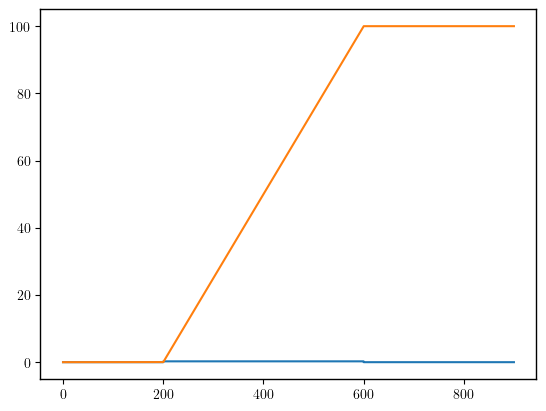

9001-element Vector{Float64}:
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  ⋮
 99.9975
 99.9975
 99.9975
 99.9975
 99.9975
 99.9975
 99.9975
 99.9975
 99.9975
 99.9975
 99.9975
 99.9975

In [560]:
#dv.heαs_kαi[:,1,:]
paso(t;t0=200,Δt=400) = t0 < t < t0+Δt ? 0.25 : 0.0 

function phi_t(t::Float64;dt::Float64 = 0.1,t_init::Float64=0.0,V=paso)
    """ Phase introduced in the boudary due 
    to time-dependence of the lead """
    tss = t_init:dt:t
    acc = V.(tss)
    ac = sum(acc)*dt#*0.001#*0.1 
end
ts = 0.0:0.1:900

plt.plot(ts,paso.(ts))
plt.plot(ts,phi_t.(ts;dt=0.01))

phase = phi_t.(ts;dt=0.01)

In [561]:
#hseα(ns,γc,nk,nσ)

## Evolution

In [562]:
### Evolution of the dynamics 
t_0 = 0.0
t_step = 0.1
t_end = 1000#50#250#100
name = "test4"
function main()
    ##### Initial conditions 
    dv, ov, lv = init_params()
    #println(1)
    n = nx*ny
    dv.vm_i1x = zeros(Float64,nx*ny,3)
    #println(2)
    #pr_spins = [PrecSpin(i) for i in 1:1:nx  ]        ### array with mutables object of preccesin spins
    dv.vm_i1x[1,1] = 1.0
    dv.vm_i1x[2,3] = 1.0  ### ojo 
    #dv.vm_i1x[2,1] = 0.0#0.1
    #dv.vm_i1x = [zeros(Float64,3) for _ in 1:n]
    ### Initiallizing the precessing classical moments to study the pumping dynamics 
    # theta_1, phi_1 = 20.0 , 0.0#45.0, 0.0 
    # period = 5 
    # pr_spins = [PrecSpin(i) for i in 1:1:n  ]        ### array with mutables object of preccesin spins
    # for jj in 1: n
    #     pr_spins[jj].i = jj ## lattice site 
    #     pr_spins[jj].theta_zero = theta_1
    #     pr_spins[jj].axis_phi = phi_1
    #     pr_spins[jj].T = period 
    #     #println(pr_spins[jj].i)
    # end
    j_sd = 0.1
    ### Set the initial hamiltonian with the precessing spins 
    # for j in 1:1:2#n #3:1:5#n_precessing#length(pr_spins)
    #     #println(j)
    #     #dv.vm_i1x[2,:] .= zeros(Float64,3)
    #     update!(pr_spins[j], 0.0 )
    #     dv.vm_i1x[pr_spins[j].i,:] .= pr_spins[j].s
    # end   
    #println(3)
    stepp(t;ti=60) = t < ti ? sin((pi/2)*t/ti)^4 : 1
    #stepp(t;ti=3,to=25) = 1/(1+exp(-(t-to)/ti))
    dv.hs_ij = hs(dv.vm_i1x,nx,ny,γ,γso,j_sd) 
    dv.hseα_ikα  = hseα(ns,γc,nk,nσ)*stepp(0.0)
    dv.heαs_kαi[:,1,:] = dv.hseα_ikα[:,:,1]'
    dv.heαs_kαi[:,2,:] = dv.hseα_ikα[:,:,2]'
    
    #println(dv.Gls_ij)
    println("Initial condition")
    ##### Setting the differential equation 
    prob = ODEProblem(eom!,dv.rkvec, (t_0,t_end), dv) #Vern7()
    integrator =  init(prob,Vern7(),dt = t_step, save_everystep=false,adaptive=true,dense=false)
    ##### Opening files to save the data
    cc_f = open("./data/cc_$(name)_jl.txt", "w+") 
    sneq_f = open("./data/sneq_$(name)_jl.txt", "w+")
    sc_f = open("./data/sc_$(name)_jl.txt", "w+") 
    cspins_f = open("./data/cspins_$(name)_jl.txt", "w+") 
    cden_f = open("./data/cden_$(name)_jl.txt", "w+") 
    ##### Setting the iterative evolution 
    println("Starting time evolution")
    println(dv.vm_i1x)
    elapsed_time = @elapsed begin
        for (i,t) in enumerate(t_0:t_step:t_end-t_step)
            tt = round((i)*t_step,digits=2)
            println("time: ", tt  )
            ### asure that time_step is printed
            flush(stdout)         
            ### evolve one time step 
            step!(integrator,t_step, true)   
            ### evaluation of observables 
            Observables!(integrator.u,ov,dv)
            ### evolution of classical dynamics 
            # #dv.vm_i1x .= heun(dv.vm_i1x,ov.sden_i1x,t_step,lv)
            if t>200
                dv.vm_i1x .= heun(dv.vm_i1x,ov.sden_i1x,t_step,lv)
                dv.vm_i1x[1,1] = 1.0
                dv.vm_i1x[1,2] = 0.0
                dv.vm_i1x[1,3] = 0.0
            end           
            # dv.vm_i1x .= heun(dv.vm_i1x,ov.sden_i1x,t_step,lv)
            # dv.vm_i1x[1,1] = 1.0
            # dv.vm_i1x[1,2] = 0.0
            # dv.vm_i1x[1,3] = 0.0
            println(dv.vm_i1x)
            ### Update parameters
            ####-----------------------Leviton-----------------------####
            # t0 = 100
            # τ = 7 
            # dv.heα_kα[1:2:end,1] .= lev(t;t0,τ)
            # dv.heα_kα[2:2:end,1] .= lev(t;t0,τ)
            ####----------------------Gaussian Pulse-----------------####
            # t0 = 50
            # τ = 1
            # A = 0.5
            # dv.heα_kα[1:2:end,1] .= gauss(t;A,t0,τ)#A*exp(-(t-t0)^2/(2*τ^2))
            # dv.heα_kα[2:2:end,1] .= gauss(t;A,t0,τ)#A*exp(-(t-t0)^2/(2*τ^2))
            ####----------------------Precesion-----------------------####
            # for j in 1:1:2#n #3:1:5#n_precessing#length(pr_spins)
            #     #println(j)
            #     #dv.vm_i1x[2,:] .= zeros(Float64,3)
            #     update!(pr_spins[j], tt )
            #     dv.vm_i1x[pr_spins[j].i,:] .= pr_spins[j].s
            # end   
            ### update hamiltonian 
            dv.hs_ij = hs(dv.vm_i1x,nx,ny,γ,γso,j_sd)#j_sd*stepp(t;ti=80)) 
            #### The voltage is used at t0=200 ### Only the left side is 
            dv.hseα_ikα = hseα(ns,γc,nk,nσ)*stepp(t)#*exp(1im*phi_t(t;dt=0.01))
            dv.hseα_ikα[:,:,1]  = hseα(ns,γc,nk,nσ)[:,:,1]*stepp(t)*exp(-1im*phi_t(t;dt=0.01))
            dv.hseα_ikα[:,:,2]  = hseα(ns,γc,nk,nσ)[:,:,2]*stepp(t)
            #dv.hseα_ikα[:,2,:]  = hseα(ns,γc,nk,nσ)[:,2,:]*stepp(t)
            
            dv.heαs_kαi[:,1,:] = dv.hseα_ikα[:,:,1]'
            dv.heαs_kαi[:,2,:] = dv.hseα_ikα[:,:,2]'
            #integrator.p.hs_ij = dv.hs_ij = hs(dv.vm_i1x,nx,ny,γ,γso,j_sd) 
            #println(dv.vm_i1x)
            #dv.heαs_kαi[1,1,1] = 0.5*exp(-(t-tγ)^2/(2*τ^2))
            #hs(dv.vm_a1x,p)
            #println(sum(dv.gl_kα[:,1]))
            println(-1im*dv.Gls_ij[1,1])
            # println(ov.scurr_xα)
            #println(-1im*(dv.Gls_ij[1,1]+dv.Gls_ij[2,2]))
            #println(-1im*(dv.Gls_ij[3,3]+dv.Gls_ij[4,4]))
            ### save the data 
            
            writedlm(cc_f, real(ov.curr_α), ' ' )
            writedlm(sneq_f, real(ov.sden_i1x), ' ' )
            writedlm(sc_f, real(ov.scurr_xα ), ' ' )
            writedlm(cspins_f,real(dv.vm_i1x), ' ' )
            writedlm(cden_f, real(ov.cden_i), ' ' )
            #### After 1 evolution step we modify the hamiltonian of the lead 
            #### in order to get an initial zero current 
            # heα_kα = heα([0.05,0.0],γ,nk,nσ)#::Array{ComplexF64,2} 
            # @tullio heαs_kαi[k,α,i] := hseα_ikα[i,k,α]#::Array{ComplexF64,3} 
            # dv.heα_kα = heα_kα
            # dv.heαs_kαi = heαs_kαi
            # integrator.p.heα_kα = heα_kα
            # integrator.p.heαs_kαi = heαs_kαi
        end
    end
    close(cc_f)
    close(cden_f)
    close(sneq_f)
    close(sc_f)
    close(cspins_f )
    println("Total time of simulation: ", elapsed_time, " s" )
    nothing 
end

main (generic function with 1 method)

In [563]:
main()

Initial condition
Starting time evolution
[1.0 0.0 0.0; 0.0 0.0 1.0]
time: 0.1
[1.0 0.0 0.0; 0.0 0.0 1.0]
0.0 + 0.0im
time: 0.2
[1.0 0.0 0.0; 0.0 0.0 1.0]
0.0 + 0.0im
time: 0.3
[1.0 0.0 0.0; 0.0 0.0 1.0]
1.1006076621151775e-23 + 3.8942211374011094e-39im
time: 0.4
[1.0 0.0 0.0; 0.0 0.0 1.0]
3.1774529210430482e-21 - 2.9237451952275748e-36im
time: 0.5
[1.0 0.0 0.0; 0.0 0.0 1.0]
1.053638994386021e-19 - 6.9260238573633195e-34im
time: 0.6
[1.0 0.0 0.0; 0.0 0.0 1.0]
1.370637890662595e-18 + 2.2560005606637742e-33im
time: 0.7
[1.0 0.0 0.0; 0.0 0.0 1.0]
1.0442320042230514e-17 + 1.645468774174023e-32im
time: 0.8
[1.0 0.0 0.0; 0.0 0.0 1.0]
5.612592069174311e-17 - 2.0238979801283394e-31im
time: 0.9
[1.0 0.0 0.0; 0.0 0.0 1.0]
2.3582235871550363e-16 + 2.64520454146723e-30im
time: 1.0
[1.0 0.0 0.0; 0.0 0.0 1.0]
8.247959639545726e-16 - 6.924009675555963e-30im
time: 1.1
[1.0 0.0 0.0; 0.0 0.0 1.0]
2.5026872305160536e-15 - 1.6951946962052205e-29im
time: 1.2
[1.0 0.0 0.0; 0.0 0.0 1.0]
6.780009921638902e-15

Excessive output truncated after 524293 bytes.

[1.0 0.0 0.0; -0.9990300115442794 0.020498402469560136 -0.03897244577945965]


## Figures

#### Load data

In [564]:
using PyPlot
using DelimitedFiles
const plt = PyPlot
# Set rcParams in Julia
plt.rc("axes", linewidth=1)  # Set the linewidth of the plot axes
plt.rc("text", usetex=true)  # Enable LaTeX rendering of text

In [565]:
name = "test4"#"test"#A_U_0.0+Omega_3.65+zs_0.0+js_0.02"
hbar = 1.0#0.658211928e0
#nx=2
n=nx*1*2

4

In [566]:
name1 = name#"test1"  # This is the active filename, uncomment others as needed
# Path definition (ensure 'path' is defined or replace it with the actual path)
path = "./data"  # Make sure to define or replace this with the correct path
#--------------------------------------------------------- Data from the TDNEGF code
# Loading data from text files
cspins_f = readdlm(joinpath(path, "cspins_$(name1)_jl.txt")) ;
sneq_f = readdlm(joinpath(path, "sneq_$(name1)_jl.txt"))
#seq_f = readdlm(joinpath(path, "seq_$(name1)_jl.txt"))
sc_f = readdlm(joinpath(path, "sc_$(name1)_jl.txt"))
cc_f = readdlm(joinpath(path, "cc_$(name1)_jl.txt"));
# # # #---------------------------------------------------------- Data for the density and the bond current
#bcurr1_f = readdlm(joinpath(path, "bcurr1_$(name1)_jl.txt"))
#bcurr2_f = readdlm(joinpath(path, "bcurr2_$(name1)_jl.txt"))
cden_f = readdlm(joinpath(path, "cden_$(name1)_jl.txt"));

In [567]:
#cspins_f
#Int(length(sneq_f[1:2:end,1]) )
#Int(length(sneq_f[1:n:end,1]))
sneq_f#[:,4]

20000×3 Matrix{Float64}:
  0.0           0.0           0.0
  0.0           0.0           0.0
  0.0           0.0           0.0
  0.0           0.0           0.0
  4.64626e-27  -3.42353e-41   7.12224e-30
  7.12224e-30  -1.27057e-42   4.64626e-27
  1.88268e-24  -1.70492e-36  -5.41103e-28
 -5.41103e-28  -2.163e-38     1.88268e-24
  1.00131e-22   2.00286e-35  -2.50516e-25
 -2.50516e-25  -3.78016e-37   1.00131e-22
  1.99147e-21   1.0129e-33   -9.50296e-24
 -9.50296e-24  -1.07019e-35   1.99147e-21
  2.18394e-20  -3.51807e-32  -1.59666e-22
  ⋮                          
  0.094336     -8.26507e-5    8.76153e-5
 -0.0943281     8.86273e-5   -9.41728e-5
  0.0914431    -8.61058e-5    6.90325e-5
 -0.0914333     9.65488e-5   -7.13177e-5
  0.0893908    -8.10637e-5    4.32509e-5
 -0.0893798     9.47803e-5   -4.11317e-5
  0.0883932    -6.81196e-5    1.28918e-5
 -0.0883817     8.35647e-5   -6.69547e-6
  0.0885542    -4.86677e-5   -1.89409e-5
 -0.0885429     6.41041e-5    2.84637e-5
  0.0898595    -2.474

In [568]:
#cc_f

In [569]:
#Int(length(sneq_f[1:nx:end,1]))
#cspins_tax 
n

4

In [570]:
t_eff_sn = Int(length(sneq_f[1:nx:end,1]))

t_eff_cc = Int(length(cc_f[1:2:end])) # Int(t_end/t_step)
t_eff_sc = Int(length(sc_f[1:3:end,1]))
t_eff_cs = Int(length(cspins_f[1:nx:end,1]))
t_eff_cd = Int(length(cden_f[1:n:end]));

In [571]:
sneq_ta1x = zeros(Float64,t_eff_sn, nx,3 )
#seq_ta1x = zeros(Float64,t_eff_se, n,3 )
cspins_tax = zeros(Float64,t_eff_cs, nx,3 )
cc_αt = zeros(Float64,2,t_eff_cc)
sc_αxt = zeros(Float64,2,3,t_eff_sc) ;
cden_ta1 = zeros(Float64,t_eff_cd, n) ;
#sc_αxt[1,1,:]
#sc_f[1:3:end,1]

In [572]:
#t_eff_sc

In [573]:
#t_eff_sc
#cc_f

In [574]:
#sneq_ta1x
#
#cc_αt[1,:]
#cc_αt

In [576]:
#sc_αxt

In [577]:
#cc_f[1:2:end-1]
#cc_f[2:2:end]
#sc_f

In [578]:
#-------------- Charge current -------------------
cc_αt[1,:] = cc_f[1:2:end-1] # Left Charge current
cc_αt[2,:] = cc_f[2:2:end] # Right Charge current
### X component
sc_αxt[1,1,:] = sc_f[1:3:end,1] # Left spin current
sc_αxt[2,1,:] = sc_f[1:3:end,2] # RIght spin current
# Y component
sc_αxt[1,2,:] = sc_f[2:3:end,1] 
sc_αxt[2,2,:] = sc_f[2:3:end,2]
## Z component
sc_αxt[1,3,:] = sc_f[3:3:end,1]
sc_αxt[2,3,:] = sc_f[3:3:end,2]


# #t_step = 0.1
for i in range(1,nx)
    ##### Noneq spin density 
    sneq_ta1x[:,i,:] = sneq_f[i:nx:end,:]
    ##### Eq. spin density 
    #seq_ta1x[:,i,:] = seq_f[i:n:end,:]
    # ##### Charge density  
    #cden_ta1[:,i] = cden_f[i:n:end]
    ##### Charge Spin density  
end


for i in range(1,n)
    ##### Noneq spin density 
    #sneq_ta1x[:,i,:] = sneq_f[i:n:end,:]
    ##### Eq. spin density 
    #seq_ta1x[:,i,:] = seq_f[i:n:end,:]
    # ##### Charge density  
    cden_ta1[:,i] = cden_f[i:n:end]
    ##### Charge Spin density  
end
#### Classical spin density
for i in range(1,nx ) 
    cspins_tax[:,i,:] = cspins_f[i:nx:end,:]
end
ts_sn=t_step:t_step:t_eff_sn*t_step
ts_cc=t_step:t_step:t_eff_cc*t_step
ts_sc=t_step:t_step:t_eff_sc*t_step
ts_cs=t_step:t_step:t_eff_cs*t_step
ts_cd=t_step:t_step:t_eff_cd*t_step ;
#sc_αxt[1,1,:]

In [579]:
cs = [cspins_tax[:,1,1] cspins_tax[:,1,2] cspins_tax[:,1,3] cspins_tax[:,2,1] cspins_tax[:,2,2] cspins_tax[:,2,3] ]

10000×6 Matrix{Float64}:
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 ⋮                                   ⋮
 1.0  0.0  0.0  -1.0  -0.000120641  -9.73851e-5
 1.0  0.0  0.0  -1.0  -0.000101098  -0.000114265
 1.0  0.0  0.0  -1.0  -6.71224e-5   -0.000119284
 1.0  0.0  0.0  -1.0  -2.21085e-5   -0.00011213
 1.0  0.0  0.0  -1.0   2.93624e-5   -9.36403e-5
 1.0  0.0  0.0  -1.0   8.19799e-5   -6.57275e-5
 1.0  0.0  0.0  -1.0   0.000130258  -3.12296e-5
 1.0  0.0  0.0  -1.0   0.000169125   6.33255e-6
 1.0  0.0  0.0  -

### Charge current 

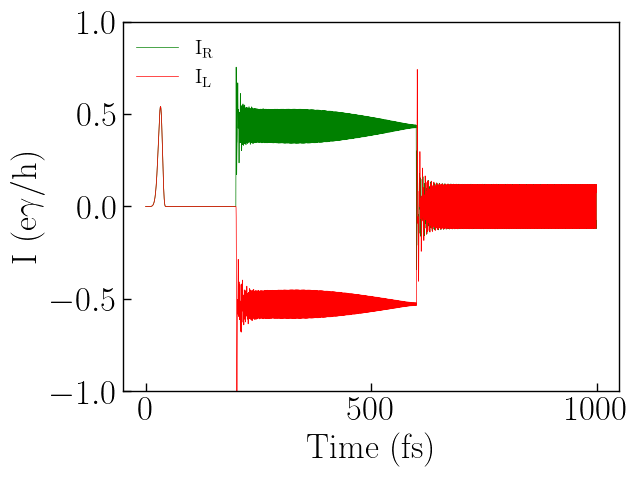

In [580]:
fig,axs = plt.subplots(1,1)
fs=25
#*1000000*1.25/2pi
axs.plot(ts_cc,cc_αt[1,:]*4pi,color= "green",lw = 0.5,label = raw"$\mathrm{I_R}$")
axs.plot(ts_cc,cc_αt[2,:]*4pi,color= "red",lw = 0.5,label = raw"$\mathrm{I_L}$")
axs.set_ylabel(L"$\mathrm{I\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
#plt.xlim(0.0,250)
# plt.axhline(0.1,ls = "--",lw=0.5)
# plt.axhline(-0.1,ls = "--",lw=0.5)
# plt.axhline(0.0,ls = "--",lw=0.5)
#plt.axhline(0.05,ls = "--",lw=0.5)
#plt.xlim(90,120)
#plt.ylim(-2,6.5)
#plt.ylim(-0.,0.1)
#plt.ylim(0.1-1e-1,0.1+1e-1)
plt.ylim(-10e-1,10e-1)
#plt.xlim(0,500)
plt.show()

In [581]:
#sc_αxt

### Spin Current 

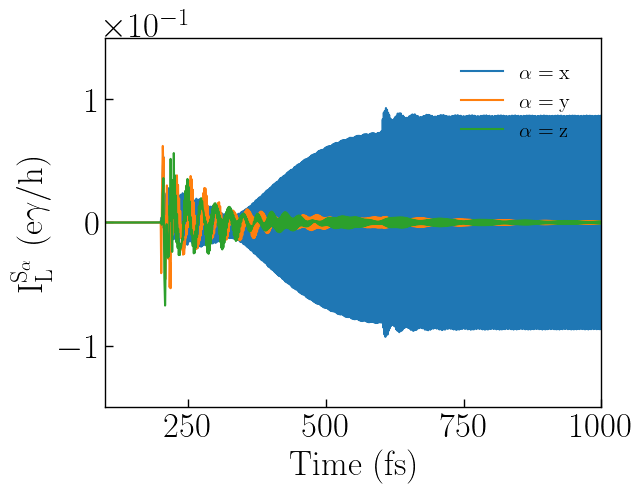

(-0.15, 0.15)

In [589]:
fig,axs = plt.subplots(1,1)
lead = 2
axs.plot(ts_sc,-sc_αxt[lead,1,:], label = raw"$\mathrm{\alpha = x}$")
axs.plot(ts_sc,-sc_αxt[lead,2,:], label = raw"$\mathrm{\alpha = y}$",ls="-")
axs.plot(ts_sc,-sc_αxt[lead,3,:], label = raw"$\mathrm{\alpha = z}$")

# axs.plot(ts_sc,sc_αxt[2,1,:], label = raw"$\mathrm{\alpha = x}$")
# axs.plot(ts_sc,sc_αxt[2,2,:], label = raw"$\mathrm{\alpha = y}$",ls=":")
# axs.plot(ts_sc,sc_αxt[2,3,:], label = raw"$\mathrm{\alpha = z}$")
axs.set_ylabel(raw"$\mathrm{I^{S_{\alpha}}_L\ (e\gamma/h)}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#plt.xlim(120,150)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.7))
plt.xlim(100,1000)
plt.ylim(-1.5e-1,1.5e-1)

### Spin density

In [590]:
#sneq_ta1x[:,site,3]

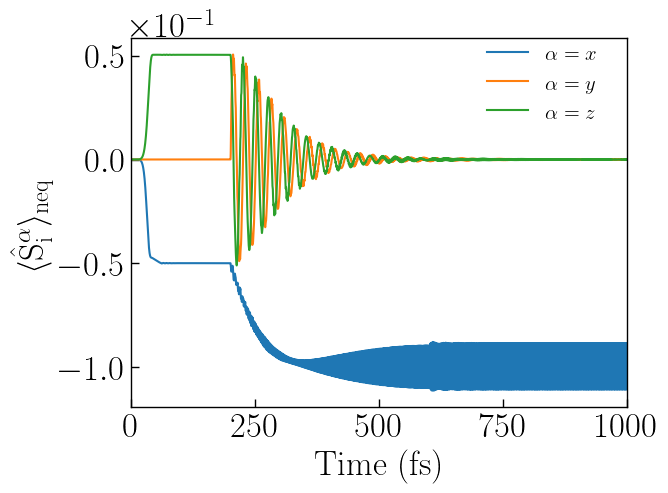

(0.0, 1000.0)

In [591]:
fig,axs = plt.subplots(1,1)
fs=25
site = 2
mag = sneq_ta1x[:,site,1].^2 +sneq_ta1x[:,site,2].^2 + sneq_ta1x[:,site,3].^2
axs.plot(ts_sn,sneq_ta1x[:,site,1],label = raw"$\alpha=x$")
axs.plot(ts_sn,sneq_ta1x[:,site,2],label = raw"$\alpha=y$")
axs.plot(ts_sn,sneq_ta1x[:,site,3],label = raw"$\alpha=z$")
#plt.plot(ts_sn,mag)
# plt.axhline(0.05,ls = "--",lw=0.5)
# plt.axhline(-0.05,ls = "--",lw=0.5)
axs.set_ylabel(raw"$\langle\mathrm{\hat{S}^{\alpha}_{i}}\rangle_{\mathrm{neq}}$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#plt.xlim(90,100)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.75))
plt.xlim(0,1000)

In [592]:
#ts_sn

### Local density 

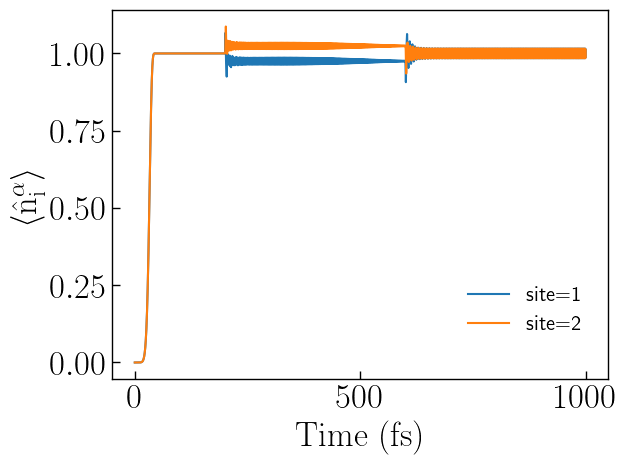

PyObject <matplotlib.legend.Legend object at 0x7f007ce4b4a0>

In [593]:
fig,axs =  plt.subplots(1,1)
site = 1
sites = range(1,6)
# for i in site 
#     axs.plot(ts_cd, cden_ta1[:,i]*det,label= "site=$(i)")#,alpha =1-0.2*i ) ### Charge bound current
#     axs.plot(ts_cd, cden_ta1[:,i+1]*det,label= "site=$(i+1)")#
# end
axs.plot(ts_cd/hbar, (cden_ta1[:,1]+cden_ta1[:,2]),label= "site=$(1)")#,alpha =1-0.2*i ) ### Charge bound current

axs.plot(ts_cd/hbar, (cden_ta1[:,4]+cden_ta1[:,3]),label= "site=$(2)")

axs.set_ylabel(raw"$\langle\mathrm{\hat{n}^{\alpha}_i}\rangle$", fontsize = fs)
axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
plt.legend(frameon = false, fontsize = fs-10, loc= (0.7,  0.1))
#plt.xlim(-1,400)
 #plt.axhline(0.5,ls = "--",color="gray",lw = 0.5)

#plt.ylim(1-0.01,1+0.01)
#plt.ylim(-1e-2,1e-2)

### Classical magnetization

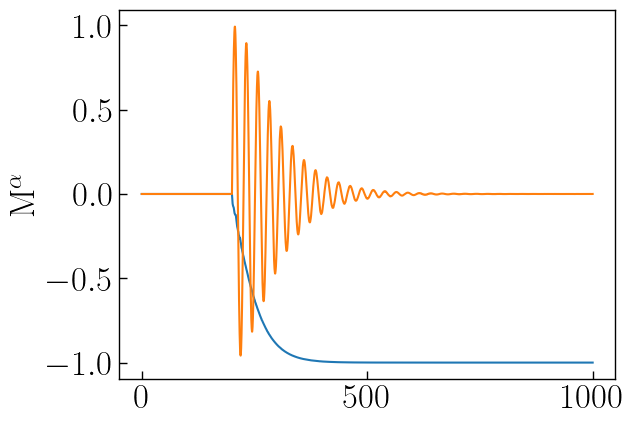

In [595]:
fig,axs = plt.subplots(1,1)
fs=25
site = 2
axs.plot(ts_cs,cspins_tax[:,site,1])
axs.plot(ts_cs,cspins_tax[:,site,2])
#axs.plot(ts_cs,cspins_tax[:,site,3])
#axs.plot(ts_cs,cspins_tax[:,site+2,3])
axs.set_ylabel(L"$\mathrm{M^{\alpha}}$", fontsize = fs)
#axs.set_xlabel(raw"$\mathrm{Time\ (fs)}$",fontsize = fs)
#axs.set_ylim([-5e-1,+5e-1])
#axs.set_ylim([-40e-1,40e-1])
axs.tick_params(axis="both", which="both", labelsize=fs,direction="in", length=6,width=1)
axs.ticklabel_format(axis="y", style="sci", scilimits=(-1,2), useMathText=true)
axs.yaxis.offsetText.set_fontsize(fs)
#axs.set_xlim([350,800])
#axs.set_xlim([950,1050])
plt.legend(frameon = false, fontsize = fs-10, loc= (0.01,  0.8))
plt.show()
#axs.set_xlim(1800,2100)
# axs.set_xlim(100,1000)
# axs.set_xlim(0,50)

## Save data

In [607]:
using DelimitedFiles
path = "/home/jalil2/Documents/KBA/data"
name = "GKBA_free"#"GKBA"

"GKBA_free"

In [608]:
sc_αxt

2×3×10000 Array{Float64, 3}:
[:, :, 1] =
 0.0  0.0  0.0
 0.0  0.0  0.0

[:, :, 2] =
 0.0  0.0  0.0
 0.0  0.0  0.0

[:, :, 3] =
  7.80104e-25  -1.09178e-39  -1.06176e-27
 -1.06176e-27   1.42235e-41   7.80104e-25

;;; … 

[:, :, 9998] =
 -0.0101746   0.000394458  -0.000782752
  0.0101797  -0.000370698   0.000851048

[:, :, 9999] =
  0.0177789   0.000541338  -0.000769892
 -0.0178226  -0.000547914   0.000828267

[:, :, 10000] =
  0.0438735   0.000631511  -0.00067794
 -0.0439613  -0.000668405   0.000720018

In [609]:
sd = [sneq_ta1x[:,1,1] sneq_ta1x[:,1,2] sneq_ta1x[:,1,3] sneq_ta1x[:,2,1] sneq_ta1x[:,2,2] sneq_ta1x[:,2,3]]
sc = [sc_αxt[1,1,:] sc_αxt[1,2,:] sc_αxt[1,3,:] sc_αxt[2,1,:] sc_αxt[2,2,:] sc_αxt[2,3,:] ]
cl = [cspins_tax[:,1,1] cspins_tax[:,1,2] cspins_tax[:,1,3] cspins_tax[:,2,1] cspins_tax[:,2,2] cspins_tax[:,2,3] ]

10000×6 Matrix{Float64}:
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 1.0  0.0  0.0   0.0   0.0           1.0
 ⋮                                   ⋮
 1.0  0.0  0.0  -1.0  -0.000120641  -9.73851e-5
 1.0  0.0  0.0  -1.0  -0.000101098  -0.000114265
 1.0  0.0  0.0  -1.0  -6.71224e-5   -0.000119284
 1.0  0.0  0.0  -1.0  -2.21085e-5   -0.00011213
 1.0  0.0  0.0  -1.0   2.93624e-5   -9.36403e-5
 1.0  0.0  0.0  -1.0   8.19799e-5   -6.57275e-5
 1.0  0.0  0.0  -1.0   0.000130258  -3.12296e-5
 1.0  0.0  0.0  -1.0   0.000169125   6.33255e-6
 1.0  0.0  0.0  -

In [610]:
#sneq_ta1x[:,1,1] 
#cspins_tax[:,1,1]


### Spin density

In [611]:
#ccL_f = open("./data/ccL_GKBA_jl.txt", "w+") 
sd_f = open("$(path)/sd_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(sd_f, [ts_sn sd], ' ' )
#writedlm(ccR_f, [ts_cc -4*pi*cc_αt[1,:]], ' ' )
#close(ccL_f)
close(sd_f)

### Spin current 

In [612]:
sc_f = open("$(path)/sc_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(sc_f, [ts_sc sc], ' ' )
#writedlm(ccR_f, [ts_cc -4*pi*cc_αt[1,:]], ' ' )
#close(ccL_f)
close(sc_f)

In [613]:
cl_f = open("$(path)/cl_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(sc_f, [ts_sc sc], ' ' )
#writedlm(ccR_f, [ts_cc -4*pi*cc_αt[1,:]], ' ' )
#close(ccL_f)
close(sc_f)

In [165]:
#cc_αt[:,:]'
#ts_sneq

#sc_αt

### Charge current 


In [166]:

#ccL_f = open("./data/ccL_GKBA_jl.txt", "w+") 
cc_f = open("$(path)/cc_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(cc_f, [ts_cc -4*pi*cc_αt'], ' ' )
#writedlm(ccR_f, [ts_cc -4*pi*cc_αt[1,:]], ' ' )
#close(ccL_f)
close(cc_f)

### Local density 

In [167]:
#using DelimitedFiles
#ccL_f = open("./data/ccL_GKBA_jl.txt", "w+") 
cden_f = open("$(path)/cd_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(cden_f, [ts_cd cden_ta1], ' ' )
#close(ccL_f)
close(cden_f)

### Classical spin 

In [614]:
cs_f = open("$(path)/cl_$(name)_jl.txt", "w+") 
#writedlm(ccL_f, [sol.t*hbar 4pi*Curr_left], ' ' )
writedlm(cs_f, [ts_cs cl], ' ' )
#close(ccL_f)
close(cs_f)

In [38]:
#cden_ta1

In [130]:
ts_cs

0.1:0.1:200.0